In [3]:
!pip install iqm-client[qiskit]==23.1
!pip install pylatexenc
!pip install matplotlib


# Connect to system

In [4]:
from iqm.qiskit_iqm import IQMProvider

server_url = "https://vlq.it4i.cz/cocos"

print(f"Create CoCoS backend: {server_url}")
provider = IQMProvider(server_url)
backend = provider.get_backend()

print(f'Qubit: {backend.architecture.qubits}')

print(f'Gates: {backend.architecture.gates.keys()}')

Create CoCoS backend: https://vlq.it4i.cz/cocos
Qubit: ['QB3', 'QB4', 'QB5', 'QB6', 'QB8', 'QB10', 'QB11', 'QB12', 'QB13', 'QB14', 'QB15', 'QB16', 'QB17', 'QB19', 'QB24']
Gates: dict_keys(['move', 'cz', 'measure', 'prx', 'reset_wait'])


# Run circuit

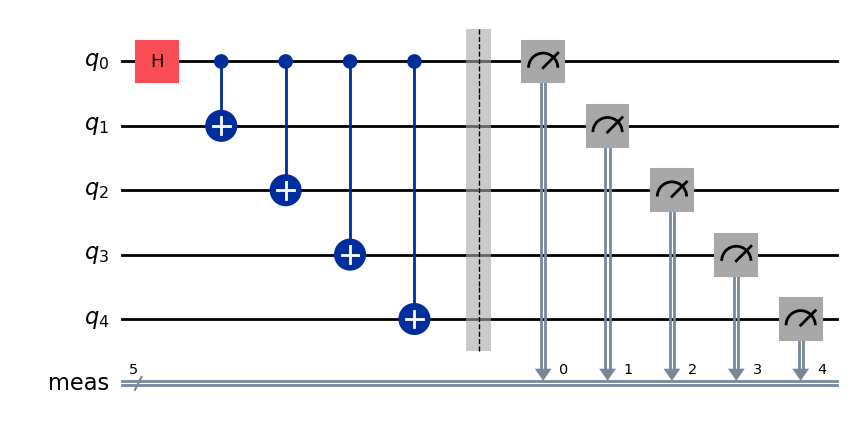

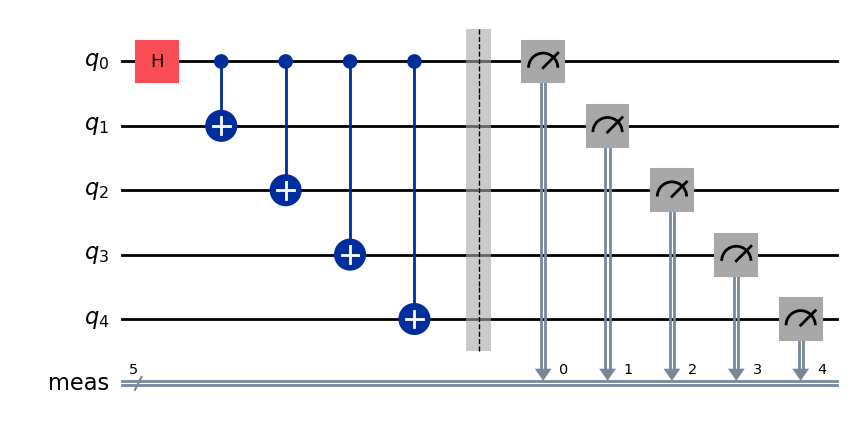

In [5]:
from qiskit import QuantumCircuit

# Define quantum circuit
num_qb = 5
qc = QuantumCircuit(num_qb)
qc.h(0)
for qb in range(1, num_qb):
    qc.cx(0, qb)
qc.measure_all()

qc.draw(output='mpl')

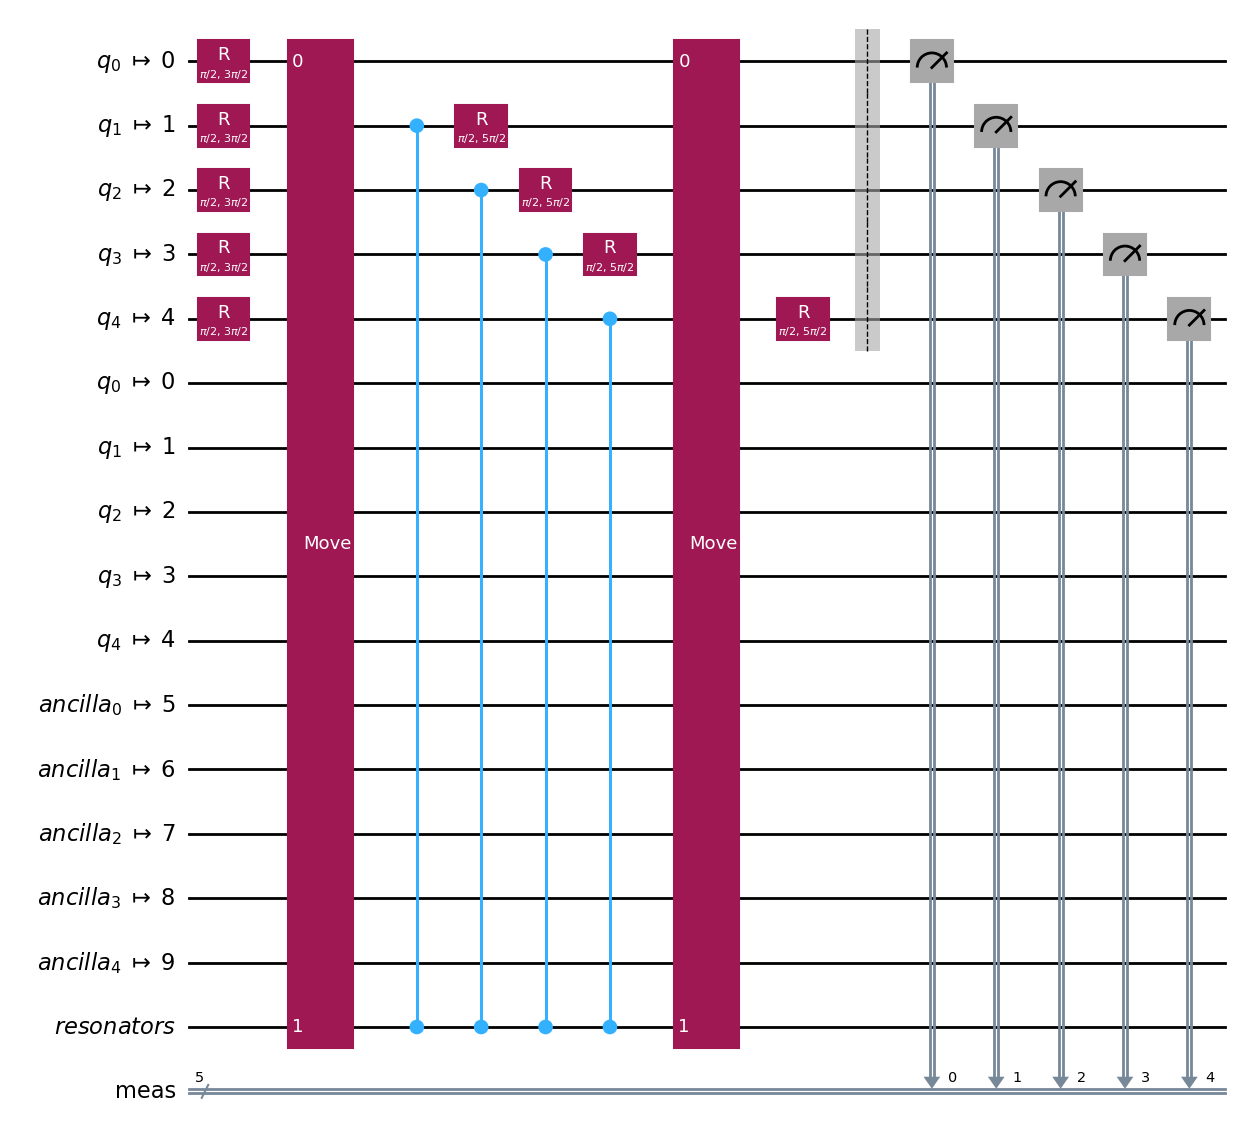

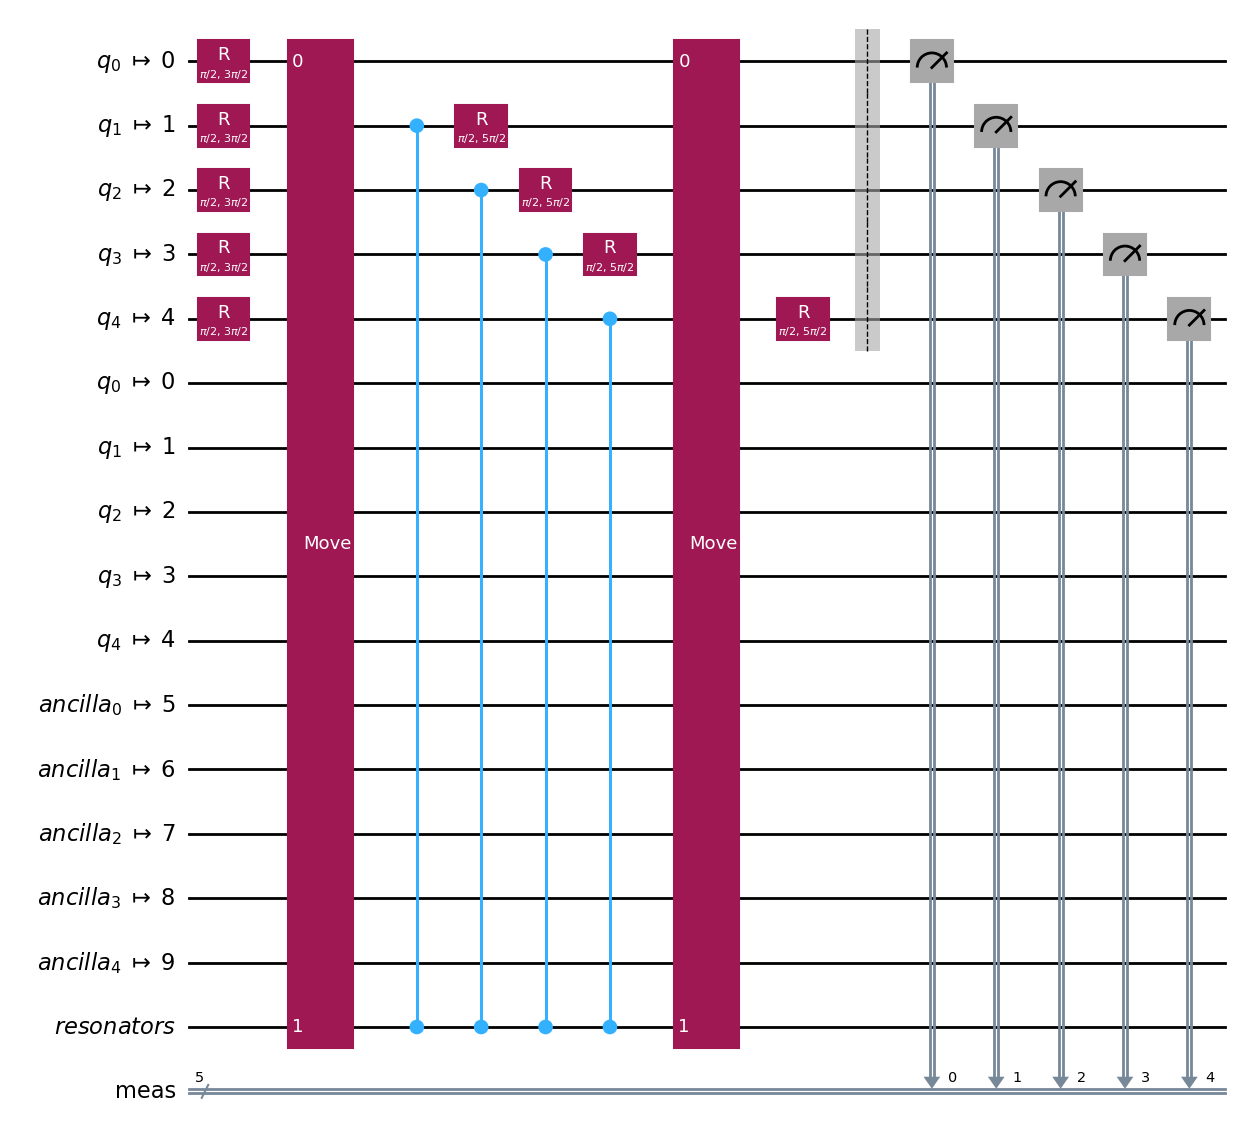

In [6]:
from iqm.qiskit_iqm import  transpile_to_IQM

# Transpile circuit
qc_transpiled = transpile_to_IQM(qc, backend)
qc_transpiled.draw(output="mpl")

{'11111': 1617, '00000': 2079, '00010': 99, '01110': 40, '11101': 132, '01111': 77, '00100': 107, '11110': 70, '10000': 69, '11001': 15, '00111': 14, '10111': 194, '01000': 202, '00110': 53, '01011': 5, '01010': 11, '10110': 16, '10101': 25, '10011': 17, '11011': 95, '11100': 7, '11000': 16, '11010': 4, '10010': 5, '01100': 18, '01101': 5, '10001': 1, '01001': 1, '10100': 4, '00011': 1, '00101': 1}


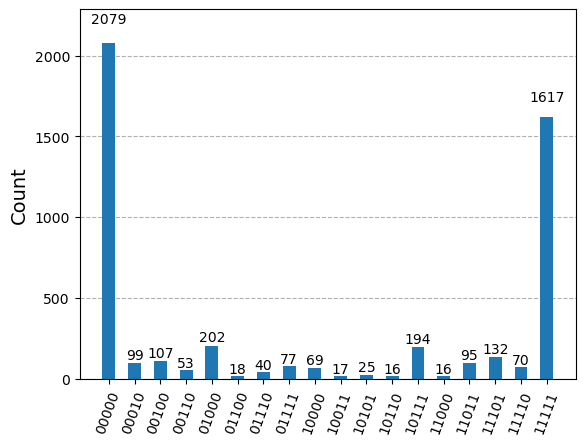

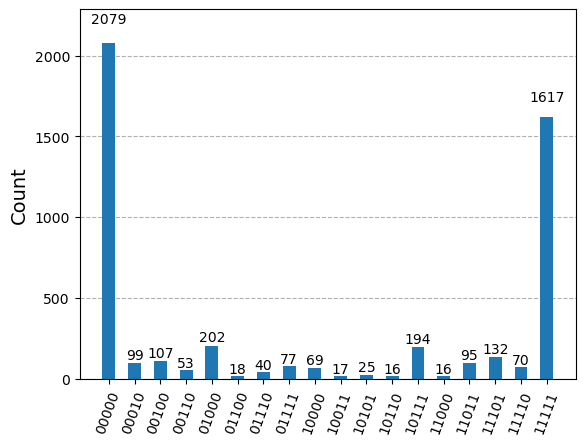

In [7]:
from qiskit.visualization import plot_histogram

# Run circuit
SHOTS = 5000

job = backend.run(qc_transpiled, shots=SHOTS)
print(job.result().get_counts())
results_dict = job.result().get_counts()

# Plot result
result_dict_copy = results_dict
result_dict_clean = {}
counts = 0
for key in result_dict_copy.keys():
    counts+= result_dict_copy[key]
    if result_dict_copy[key] > 15:
        result_dict_clean[key] = result_dict_copy[key]
display(plot_histogram(result_dict_clean))